In [76]:
#  Import necessary libraries
import numpy as np # For numerical operations 
import pandas as pd # For data manipulation 
import matplotlib.pyplot as plt # 
import seaborn as sns # For advanced data visualization 
from sklearn.preprocessing import StandardScaler # For feature scaling 
from sklearn.cluster import KMeans # For K-Means clustering 
from sklearn.decomposition import PCA # For dimensionality reduction 
from sklearn.metrics import silhouette_score # For evaluating clustering performance 
import warnings # To suppress warnings 
warnings.filterwarnings("ignore")

In [77]:

# Ignore warnings for cleaner output

In [78]:
# Step 1: Load the dataset

In [79]:
df = pd.read_csv('Mall_Customers.csv')

In [80]:
# Display the first few rows of the dataset to understand its structure

In [81]:
# print("Dataset Head:")
print(df.tail())
print(df.head())

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [82]:
#  Step 2: Data Preprocessing
 #  Handling missing values if any by dropping rows with missing data

In [83]:
df = df.dropna()

In [84]:
#  Select relevant features for segmentation
# We use 'Age', 'Annual Income (k$)', and 'Spending Score (1-100)' for clustering

In [85]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

In [86]:
# Standardize the features (important for K-Means, as it is distance-based)

In [87]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
#  Step 3: Exploratory Data Analysis (EDA)
# Visualizing relationships between features using a pairplot

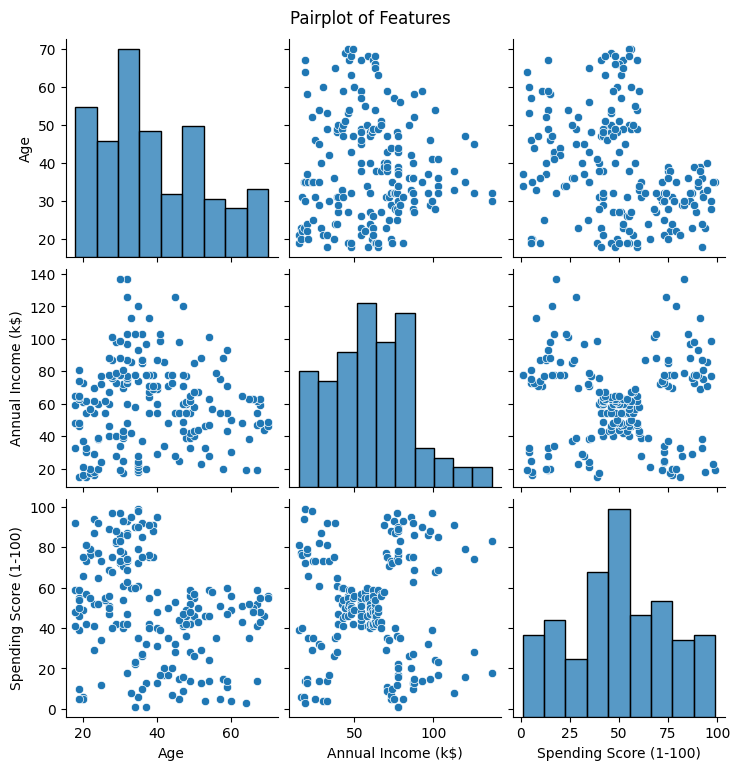

In [89]:
sns.pairplot(df[features])
plt.suptitle("Pairplot of Features", y=1.02)
plt.show()

In [90]:
#  Step 4: Determine the Optimal Number of Clusters (Elbow Method)
# The Elbow Method helps identify the optimal number of clusters by plotting WCSS (Within-Cluster-Sum-of-Squares)

In [91]:
wcss = []
cluster_range = range(1, 11)

In [92]:
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [93]:
#  Plotting  the Elbow Curve

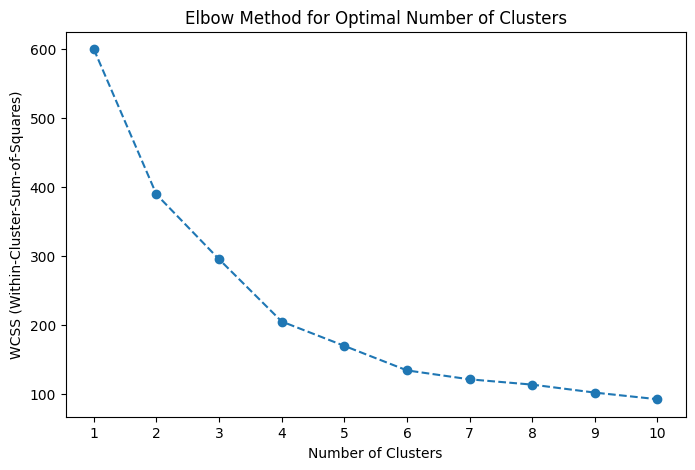

In [94]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster-Sum-of-Squares)')
plt.xticks(cluster_range)
plt.show()

In [95]:
#  Step 5: Apply K-Means Clustering
# Based on the Elbow Method, choose the optimal number of clusters

In [96]:
optimal_clusters = 5  # Adjust this based on the Elbow Curve (e.g., where the "elbow" bends)
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)   # Initialize K-Means with the optimal number of clusters
kmeans.fit(X_scaled)   # Fit the model to the scaled data

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [97]:
#  Add cluster labels to the original dataset

In [98]:
df['Cluster'] = kmeans.labels_

In [99]:
#  Step 6: Evaluate Clustering Performance
# Using the Silhouette Score to evaluate the quality of clustering
# The Silhouette Score ranges from -1 to 1, where higher values indicate better-defined clusters

In [100]:
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score: {silhouette_avg:.2f}")

Silhouette Score: 0.41


In [101]:
#  Step 7: Visualize Clusters (Using PCA for 2D Visualization)
# Reducing dimensions to 2D using PCA for easier visualization

In [102]:
pca = PCA(n_components=2)   # Initializes PCA to reduce features to 2 components
X_pca = pca.fit_transform(X_scaled)    # Transforms the scaled data into 2D

In [103]:
#  Adding PCA components to the dataframe for visualization

In [104]:
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

In [105]:
# Plotting clusters using a scatterplot

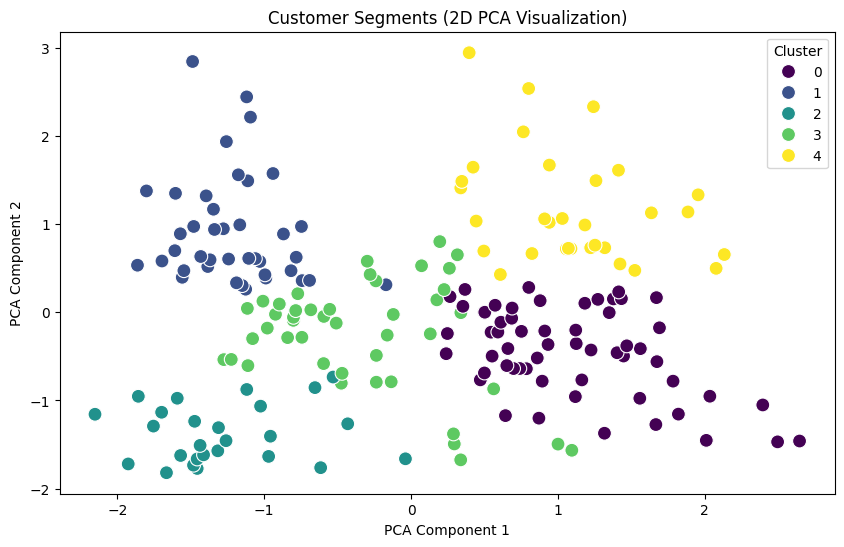

In [106]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('Customer Segments (2D PCA Visualization)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [107]:
#  Step 8: Analyze Clusters
# Grouping by cluster and analyzing the mean values of features for each cluster

In [108]:
cluster_summary = df.groupby('Cluster')[features].mean()
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        55.275862           47.620690               41.706897
1        32.875000           86.100000               81.525000
2        25.769231           26.115385               74.846154
3        26.733333           54.311111               40.911111
4        44.387097           89.774194               18.483871


In [109]:
#  Step 9: Saving the Results 
# Saving the dataframe with cluster labels to a new CSV file for further analysis

In [110]:
df.to_csv('customer_segmentation_results.csv', index=False)

print("Customer segmentation completed and results saved!")

Customer segmentation completed and results saved!


In [111]:
print("This project was created by Nishant Dubey, CSE'26")

This project was created by Nishant Dubey, CSE'26
